### Why Seaborn?
- Provides a layer of abstraction hence easier to use.
- Better aesthetics
- More graphs included

### Seaborn Roadmap
#### Types of Functions
- Figure Level
- Axis Level.

#### Main Classification
- Relational Plot
- Distribution plot
- Categorical Plot
- Regression Plot
- Matrix Plot
- Multiplots

https://seaborn.pydata.org/api.html

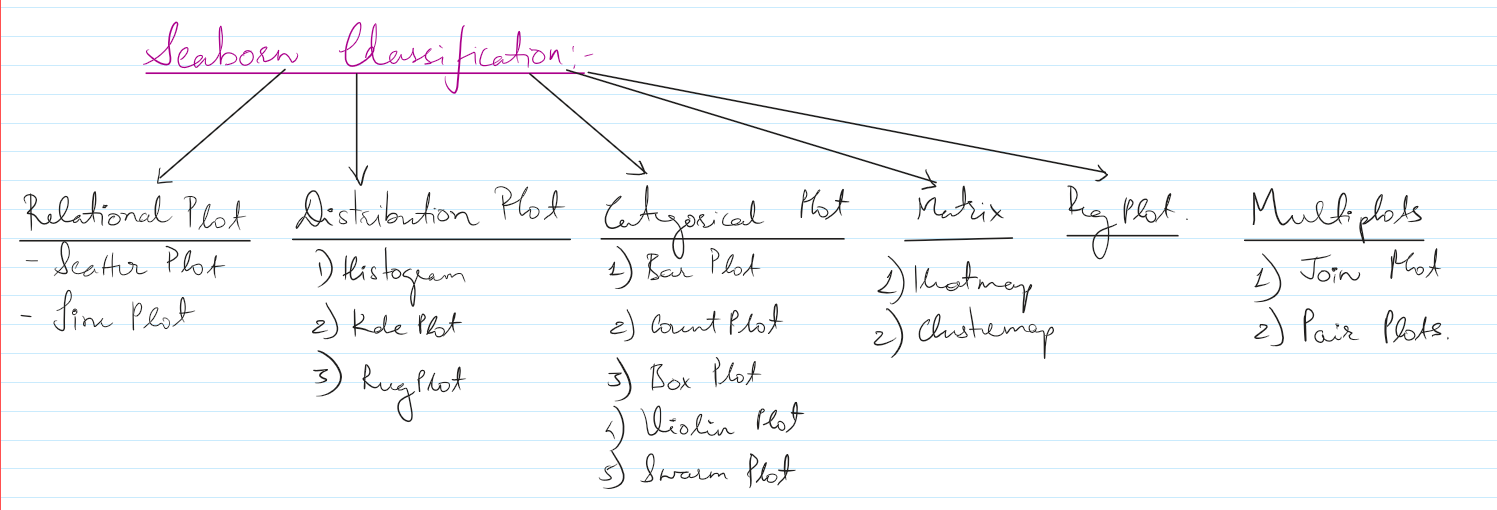

### 1. Relational Plot
- To see the statistical Relation between 2 or more variables.
- Bivariate Analysis.

#### Plots under this section 
- Scatter Plot
- Line Plot

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
tips = sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='total_bill', ylabel='tip'>

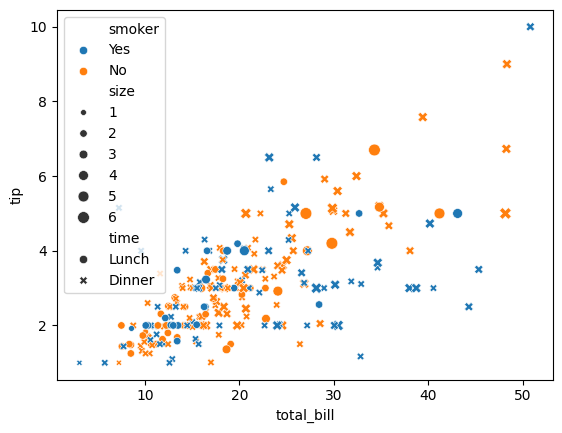

In [8]:
# scatter plot -> axes level function
sns.scatterplot(data=tips, x = 'total_bill', y = 'tip', hue='smoker',size='size',style='time')

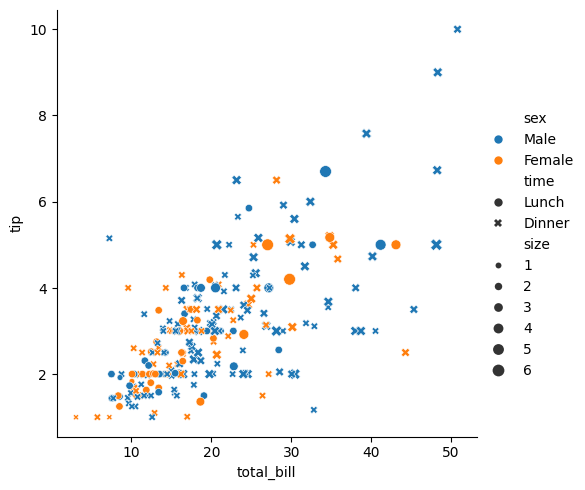

In [14]:
# rel plot -> figure level -> square shape
sns.relplot(data=tips, x='total_bill', y='tip',kind='scatter', hue='sex',size='size',style='time')

**Seaborn recommends you to use figure level function over axes level as using figure level we can make axes level graphs**.

In [17]:
# line plot
gap = px.data.gapminder()
temp_df = gap[gap['country'] == 'India']
temp_df

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
696,India,Asia,1952,37.373,372000000,546.565749,IND,356
697,India,Asia,1957,40.249,409000000,590.061996,IND,356
698,India,Asia,1962,43.605,454000000,658.347151,IND,356
699,India,Asia,1967,47.193,506000000,700.770611,IND,356
700,India,Asia,1972,50.651,567000000,724.032527,IND,356
701,India,Asia,1977,54.208,634000000,813.337323,IND,356
702,India,Asia,1982,56.596,708000000,855.723538,IND,356
703,India,Asia,1987,58.553,788000000,976.512676,IND,356
704,India,Asia,1992,60.223,872000000,1164.406809,IND,356
705,India,Asia,1997,61.765,959000000,1458.817442,IND,356


<Axes: xlabel='year', ylabel='lifeExp'>

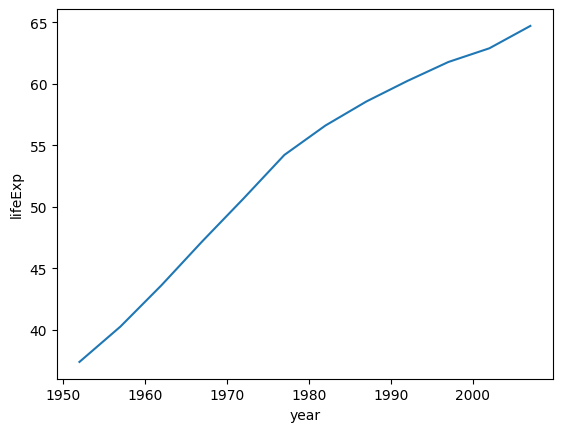

In [18]:
# axes level function
sns.lineplot(data=temp_df , x='year', y='lifeExp')

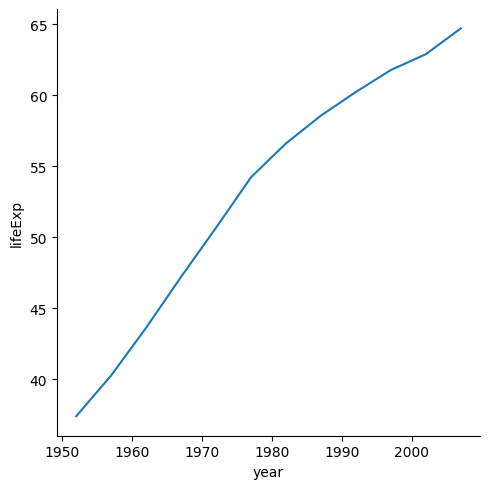

In [20]:
# using rel plot
sns.relplot(data=temp_df, x='year', y='lifeExp', kind='line')

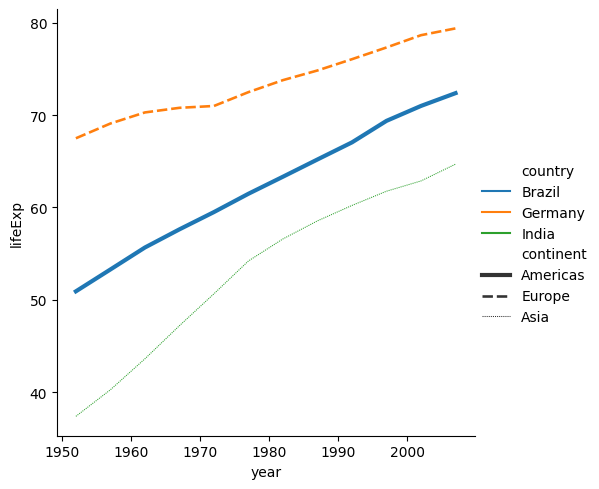

In [26]:
# hue -> style
temp_df = gap[gap['country'].isin(['India','Brazil','Germany'])]
sns.relplot(data = temp_df , x='year', y='lifeExp', kind='line', hue='country',style='continent',size='continent')

<Axes: xlabel='year', ylabel='lifeExp'>

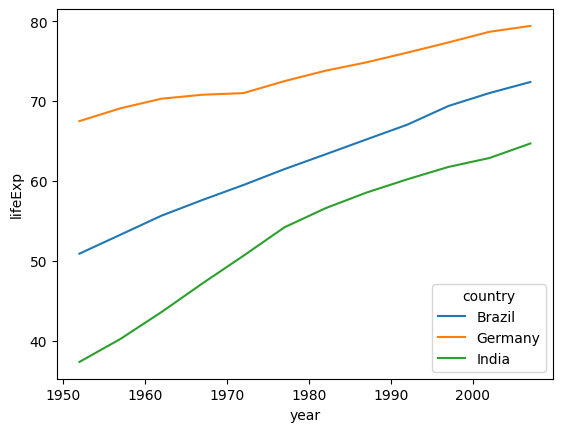

In [ ]:
sns.lineplot(data = temp_df , x='year', y='lifeExp', hue='country')

'[[Thur, Male], [Thur, Female]\n[Fri, Male], [Fri, Female]\n[Sat, Male], [Sat, Female]\n[Sun, Male], [Sun, Female]\n]'

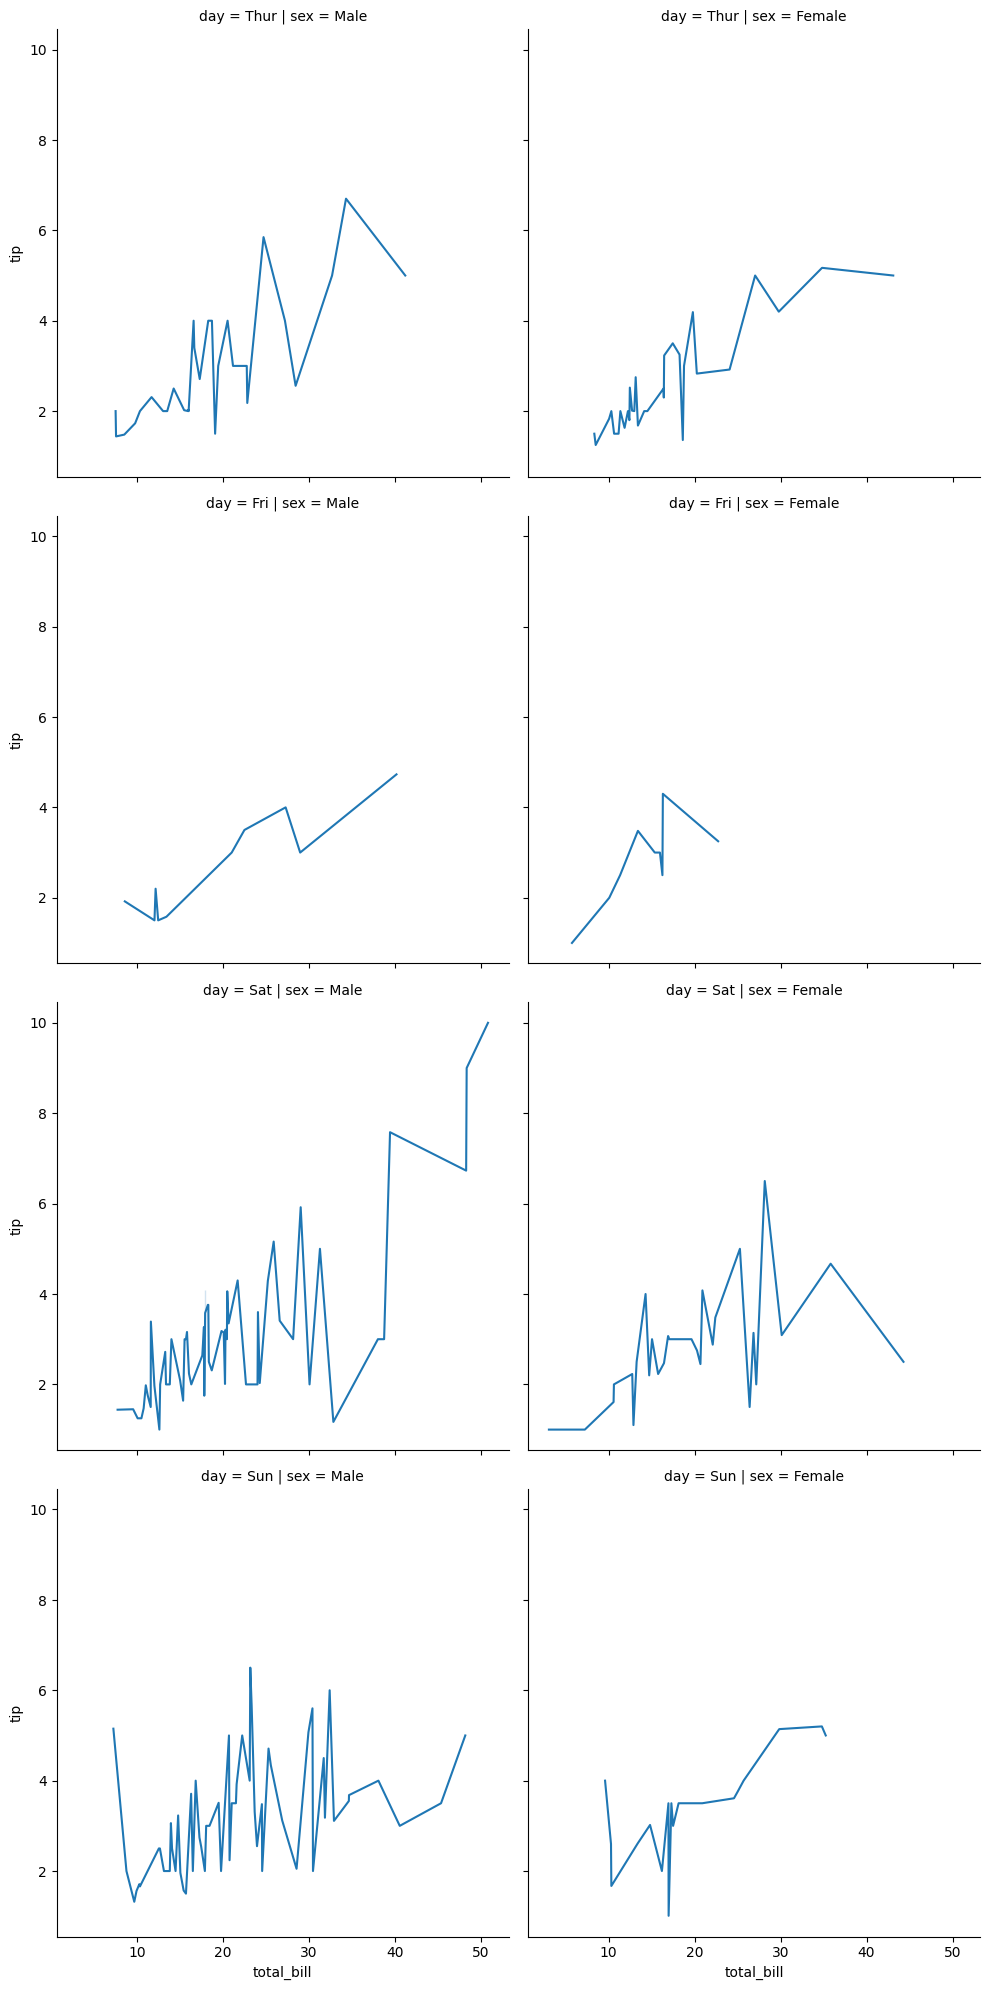

In [33]:
# facet plot -> figure level function -> work with relplot
# it will not work with scatterplot and line plot
sns.relplot(data = tips, x='total_bill', y='tip', kind='line',col='sex',row='day')
"""[[Thur, Male], [Thur, Female]
[Fri, Male], [Fri, Female]
[Sat, Male], [Sat, Female]
[Sun, Male], [Sun, Female]
]"""

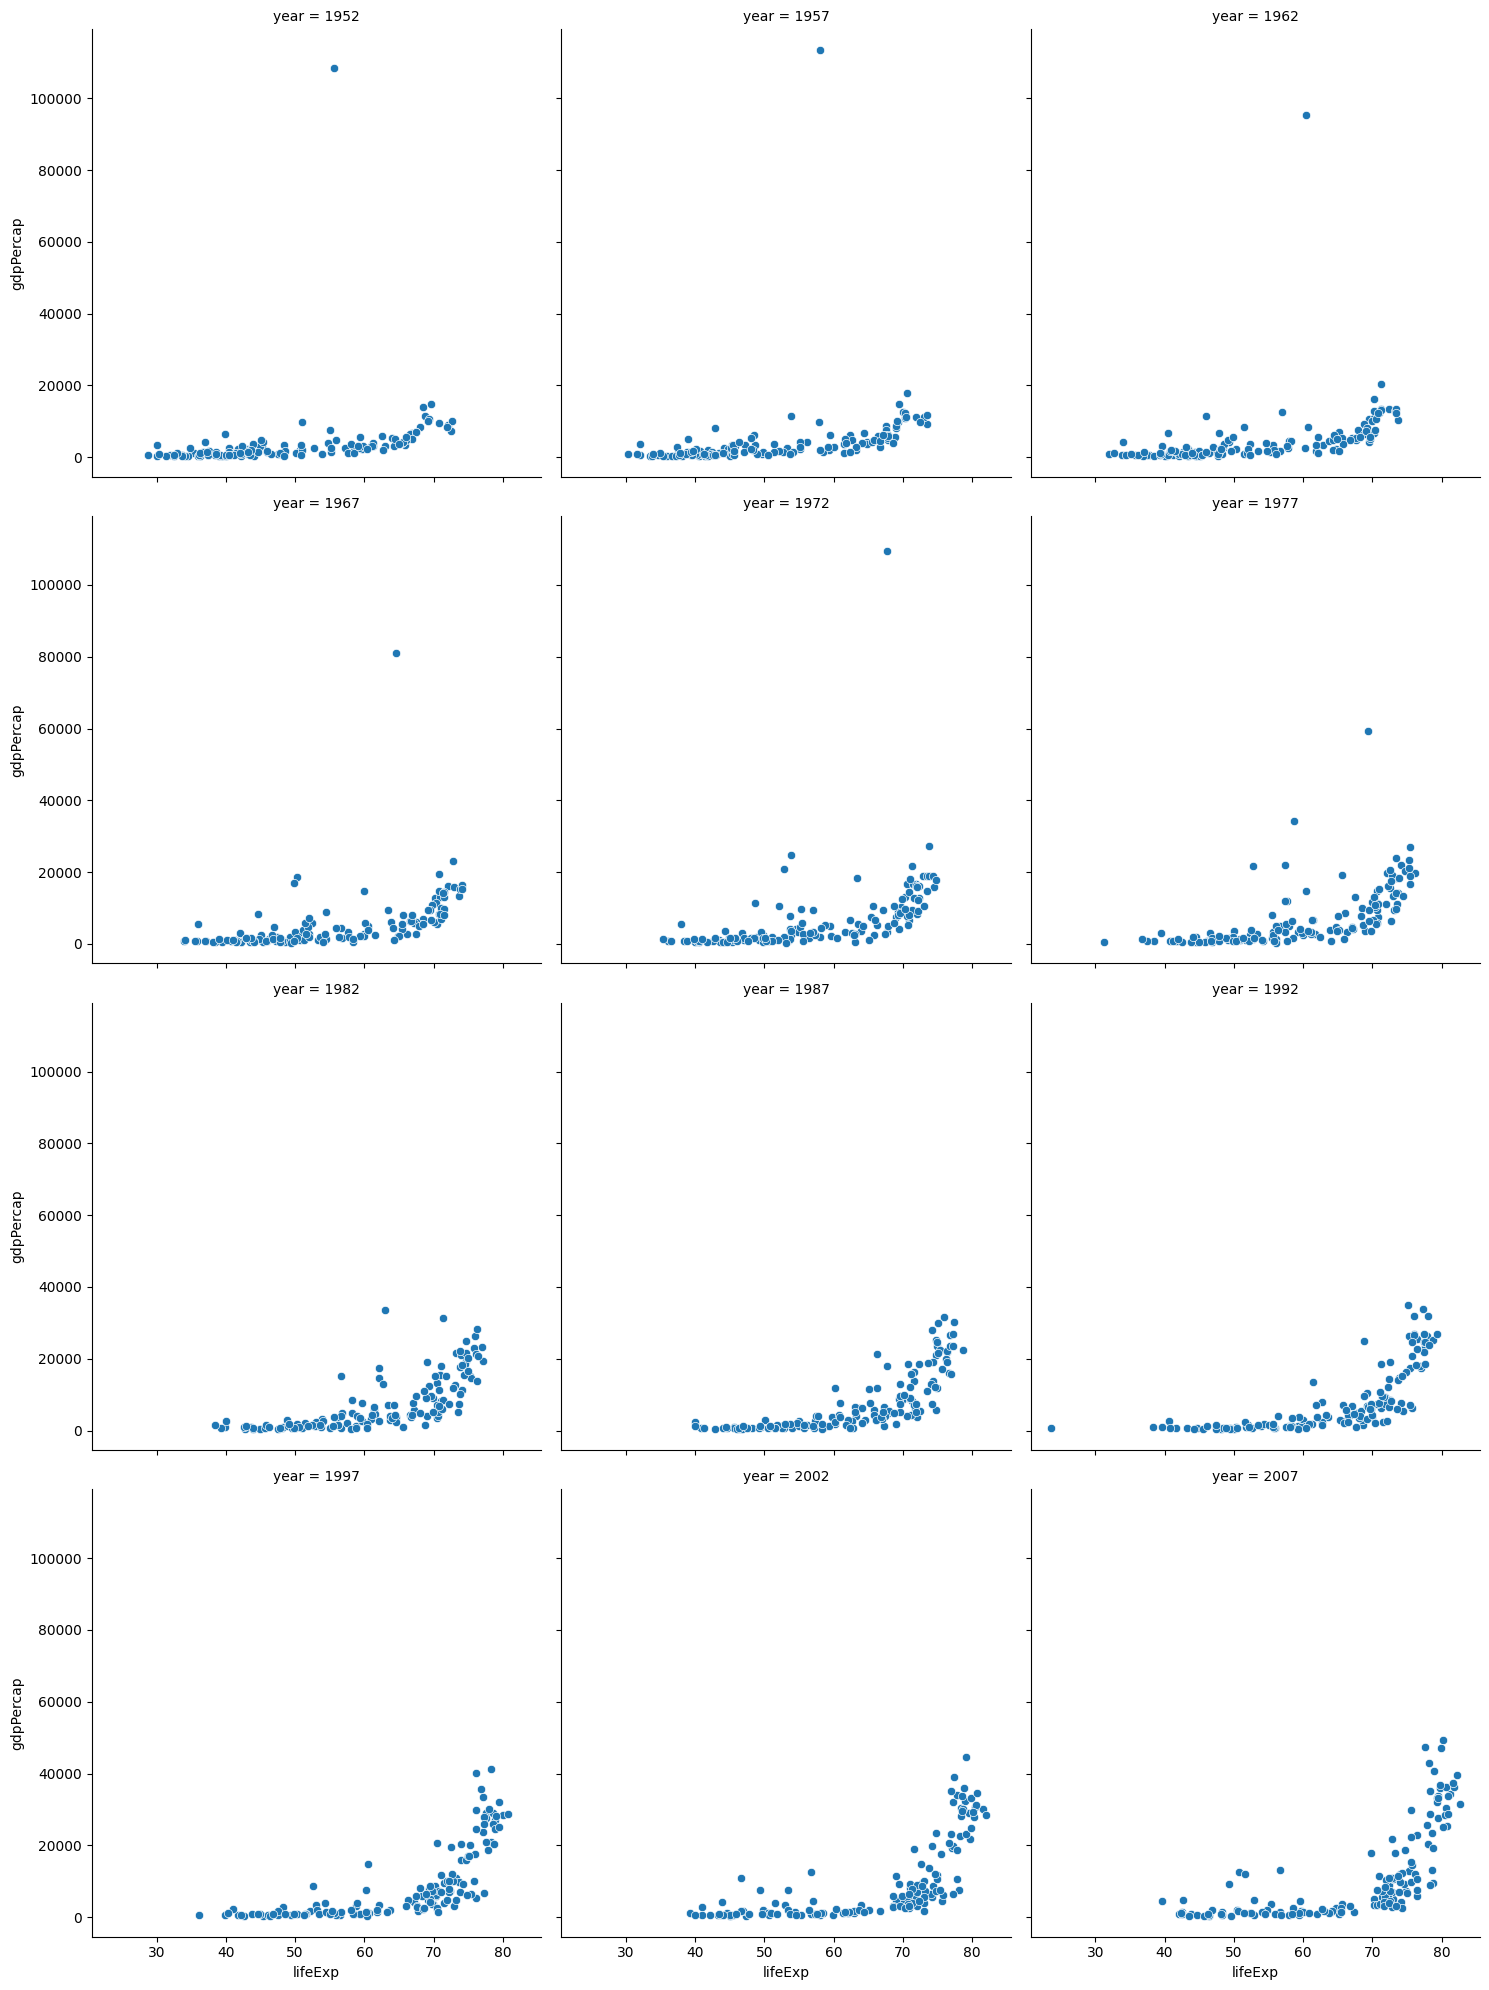

In [37]:
# col wrap
sns.relplot(data = gap, x='lifeExp', y='gdpPercap',kind='scatter',col='year',col_wrap=3)

### 2. Distribution Plots
- Used for univariate analysis
- Used to find out the distribution
- Range of the observation
- Central Tendency
- Is the data bimodal?
- Are there outliers?

### Plots under Distribution plot
- histplot
- kdeplot
- rugplot

In [38]:
# figure level -> distplot
# axes level -> histplot -> kdeplot -> rugplot

<Axes: xlabel='total_bill', ylabel='Count'>

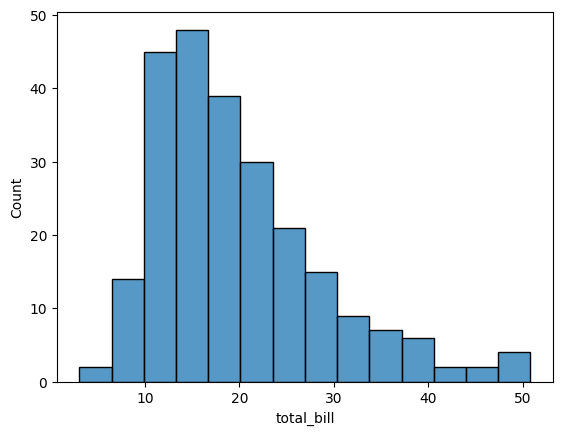

In [43]:
# plotting univariate histogram
sns.histplot(data=tips, x='total_bill')

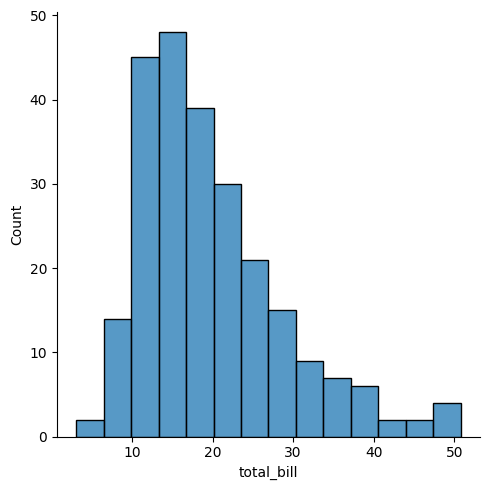

In [48]:
sns.displot(data=tips,x='total_bill',kind='hist')

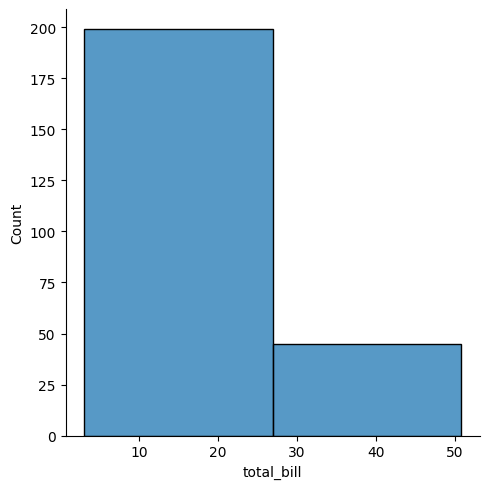

In [49]:
# bins parameter
sns.displot(data=tips,x='total_bill',kind='hist',bins=2)

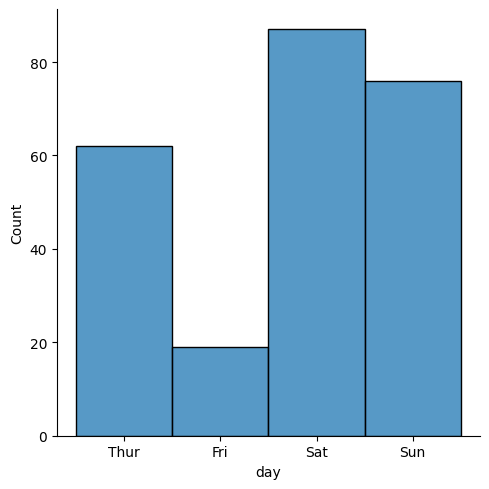

In [54]:
# Generally histogram is used for numerical variable
# But histogram can also be plot for categorical variables using -> count plot
# Discrete bins are automatically set for categorical variables

# count plot
sns.displot(data = tips, x='day', kind='hist')

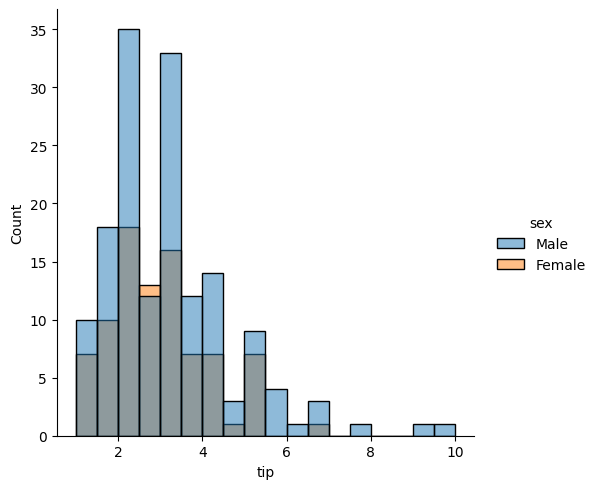

In [57]:
# hue parameter
sns.displot(data = tips, x='tip', kind='hist', hue='sex')

`element='step`
- Instead of filled bars, Seaborn draws only the outlines (steps) of the histogram bins.

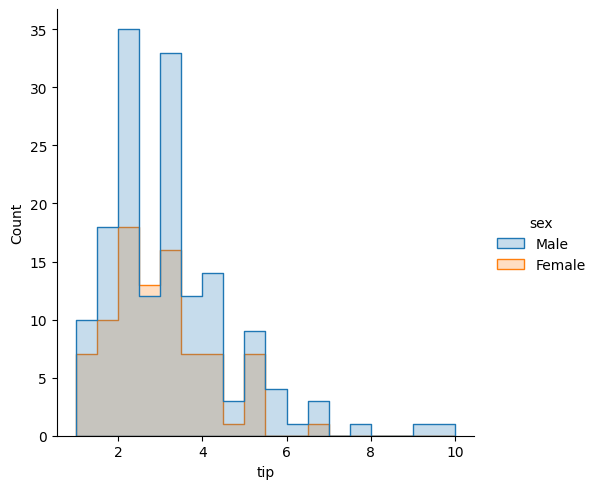

In [58]:
# element -> step
sns.displot(data=tips, x='tip', kind='hist',hue='sex',element='step')

In [60]:
titanic = sns.load_dataset('titanic')
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


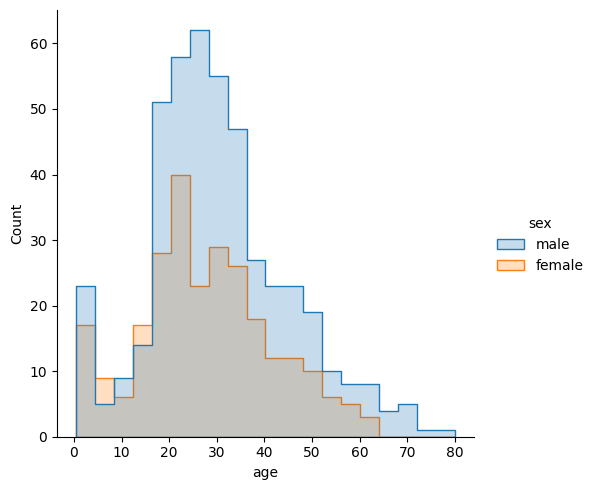

In [65]:
sns.displot(data = titanic, x='age', kind='hist', hue='sex', element='step')

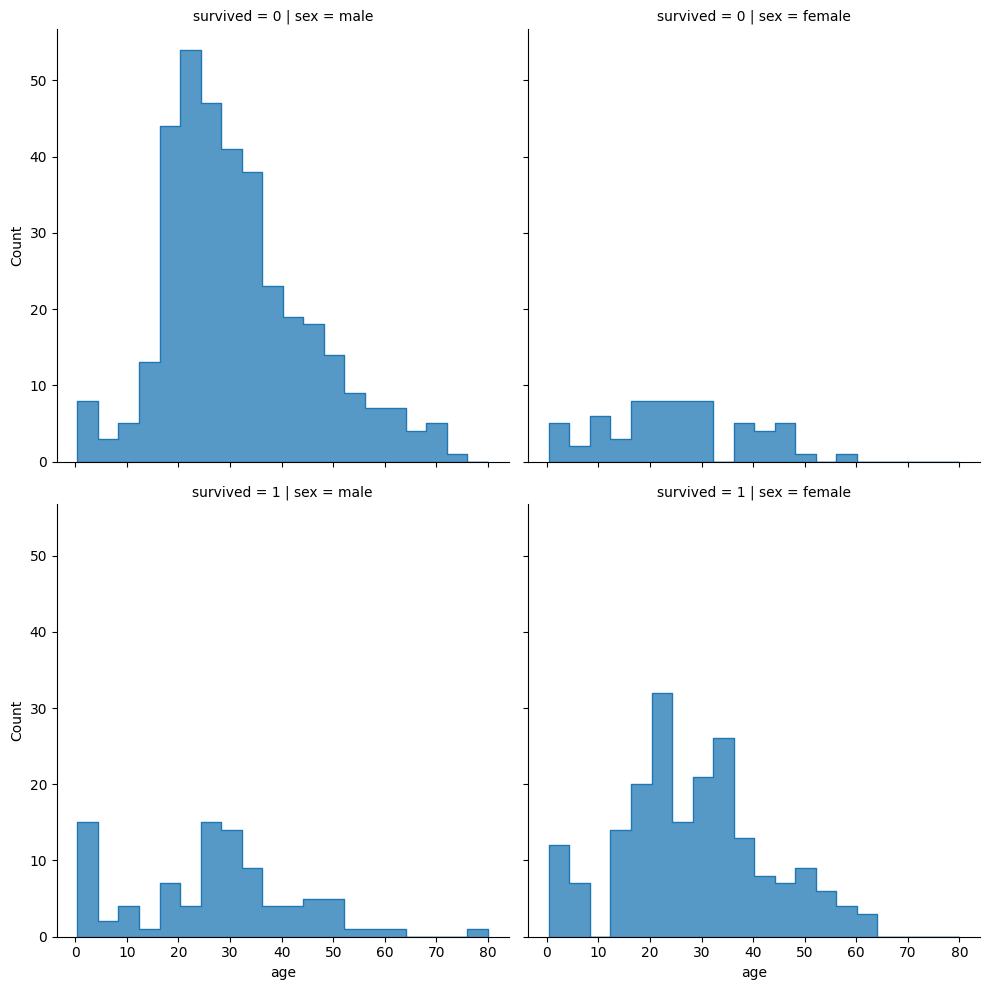

In [71]:
# faceting using col and row -> not work on histplot function
sns.displot(data=titanic, x='age', kind='hist',col='sex',element='step',row='survived')

<Axes: xlabel='total_bill', ylabel='Density'>

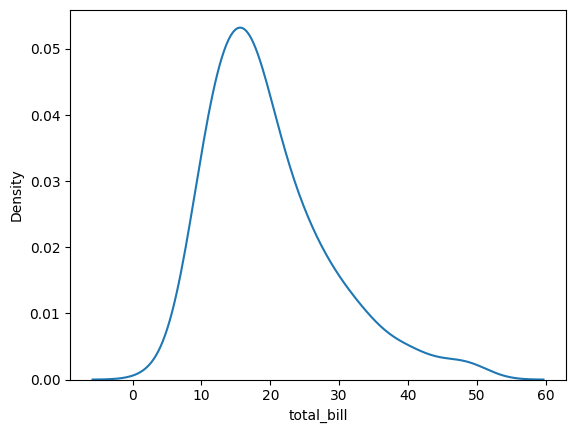

In [72]:
# kdeplot
# Rather than using discrete bins, a KDE plot smooths the observations with a Gaussian kernel, producing a continuous density estimate
sns.kdeplot(data=tips,x='total_bill')

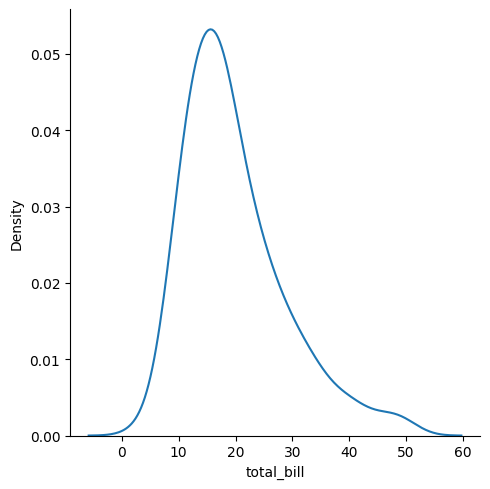

In [73]:
sns.displot(data=tips,x='total_bill',kind='kde')

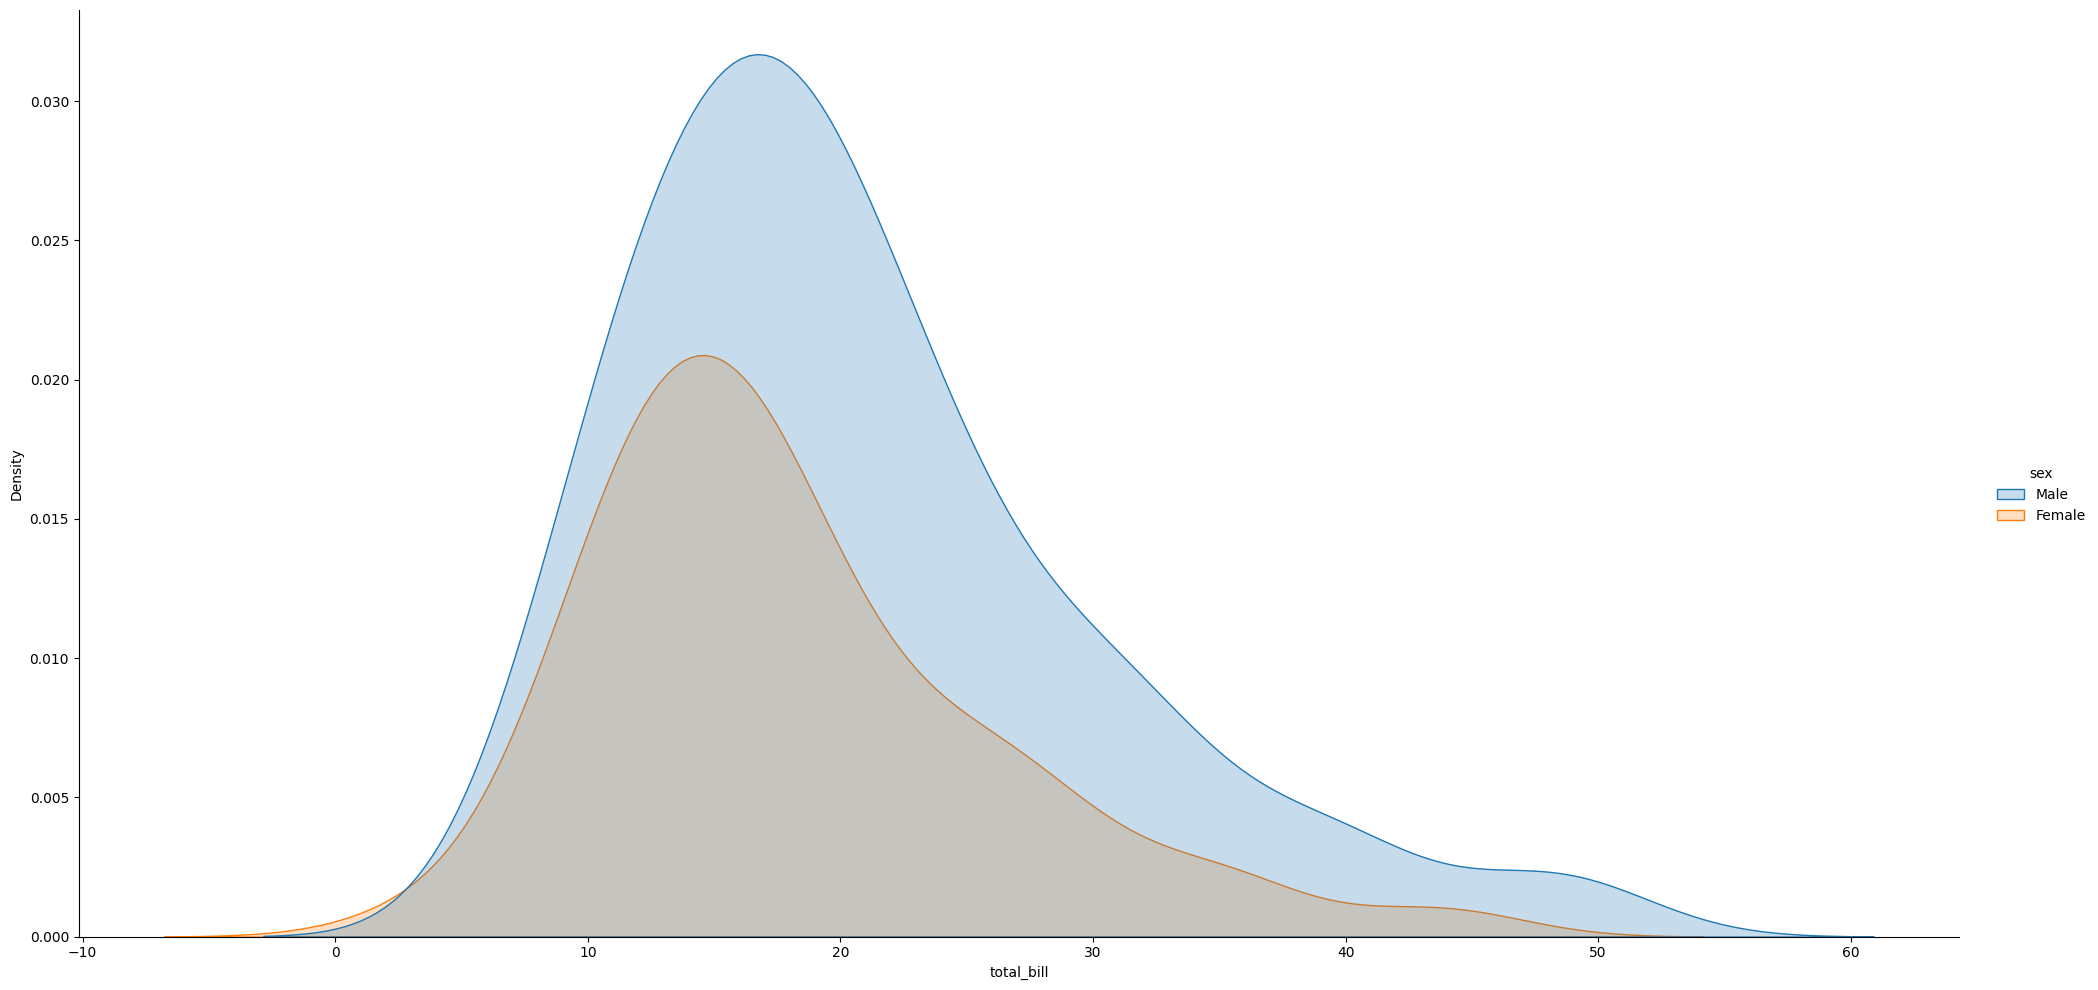

In [79]:
# hue -> fill
sns.displot(data=tips, x='total_bill' ,kind='kde', hue='sex',fill=True,height=10,aspect=2)

In [ ]:
# Rug plot
# plot Marginal Distribution by drawing ticks along the x and y axes.
# This function is intended to complement other plots by showing the location of
# individual observations in an unobtrusive way


<Axes: xlabel='total_bill', ylabel='Density'>

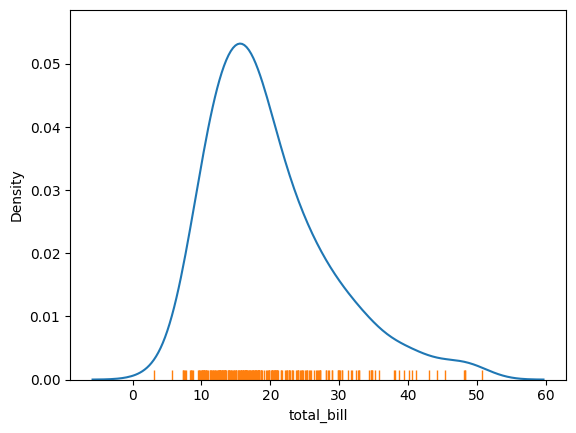

In [86]:
sns.kdeplot(data=tips, x='total_bill')
sns.rugplot(data=tips, x='total_bill')

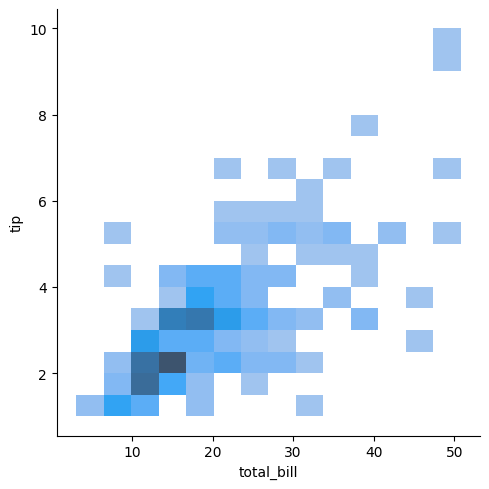

In [88]:
# Bivariate Histogram
# A Bivariate histogram bins the data within rectangle that tile the plot
# and then shows the count of observations within each rectangle with the fill color

# sns.histplot(data = tips, x='total_bill', y='tip')
sns.displot(data = tips, x='total_bill', y='tip',kind='hist')

<Axes: xlabel='total_bill', ylabel='tip'>

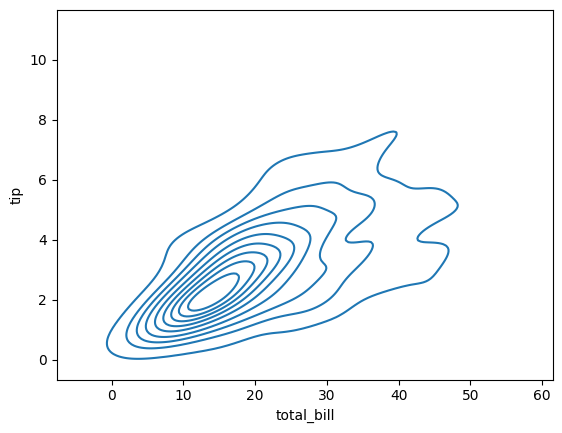

In [89]:
# Bivariate kdeplot
# A Bivariate KDE plot smoothes the (x,y) observations with a 2D Gaussian
sns.kdeplot(data = tips, x='total_bill', y='tip')

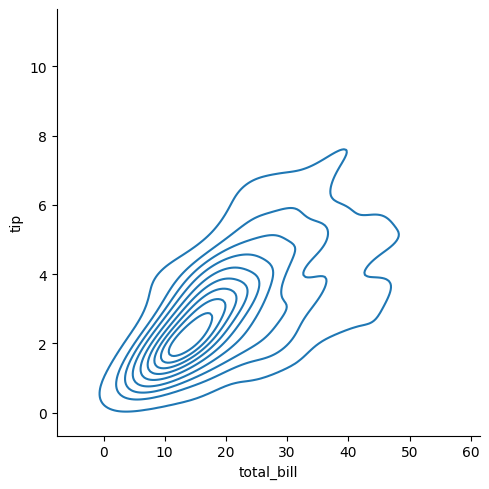

In [90]:
sns.displot(data = tips, x='total_bill', y='tip',kind='kde')

### 2. Matrix Plot
- Heatmap
- Clustermap

<Axes: xlabel='year', ylabel='country'>

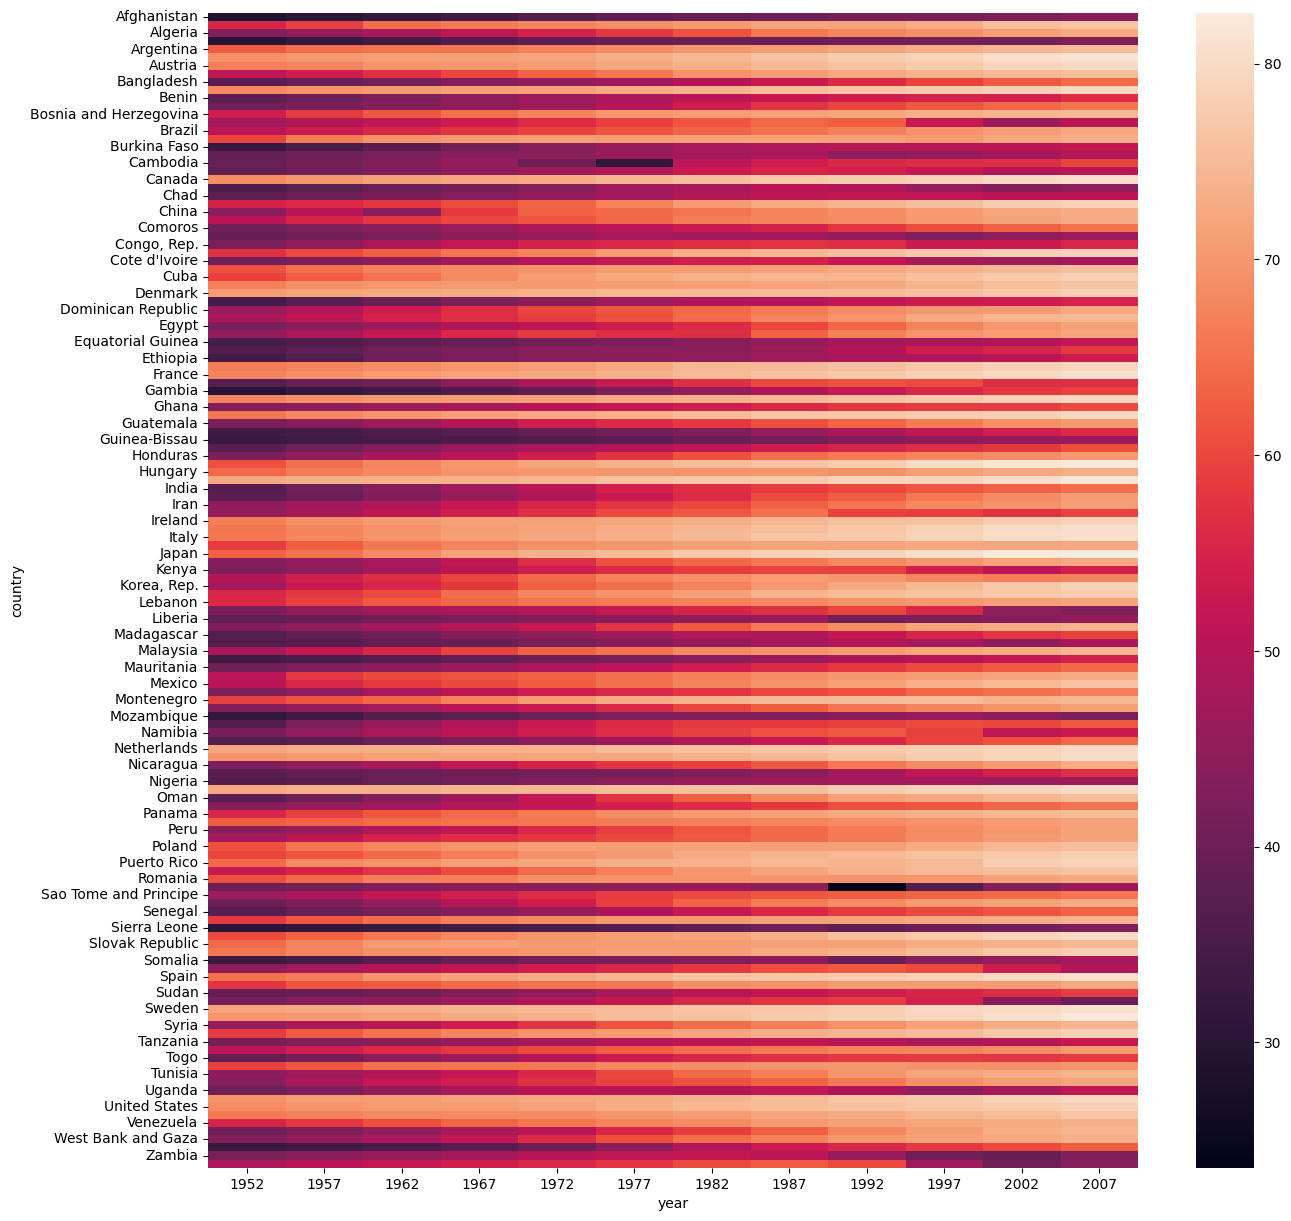

In [96]:
# Heatmap -> already a axes level function
# Plot rectangular data as a color-encoded matrix
temp_df = gap.pivot(index='country', columns='year', values='lifeExp')
temp_df

# axes level function
plt.figure(figsize=(15,15))
sns.heatmap(temp_df)

<Axes: xlabel='year', ylabel='country'>

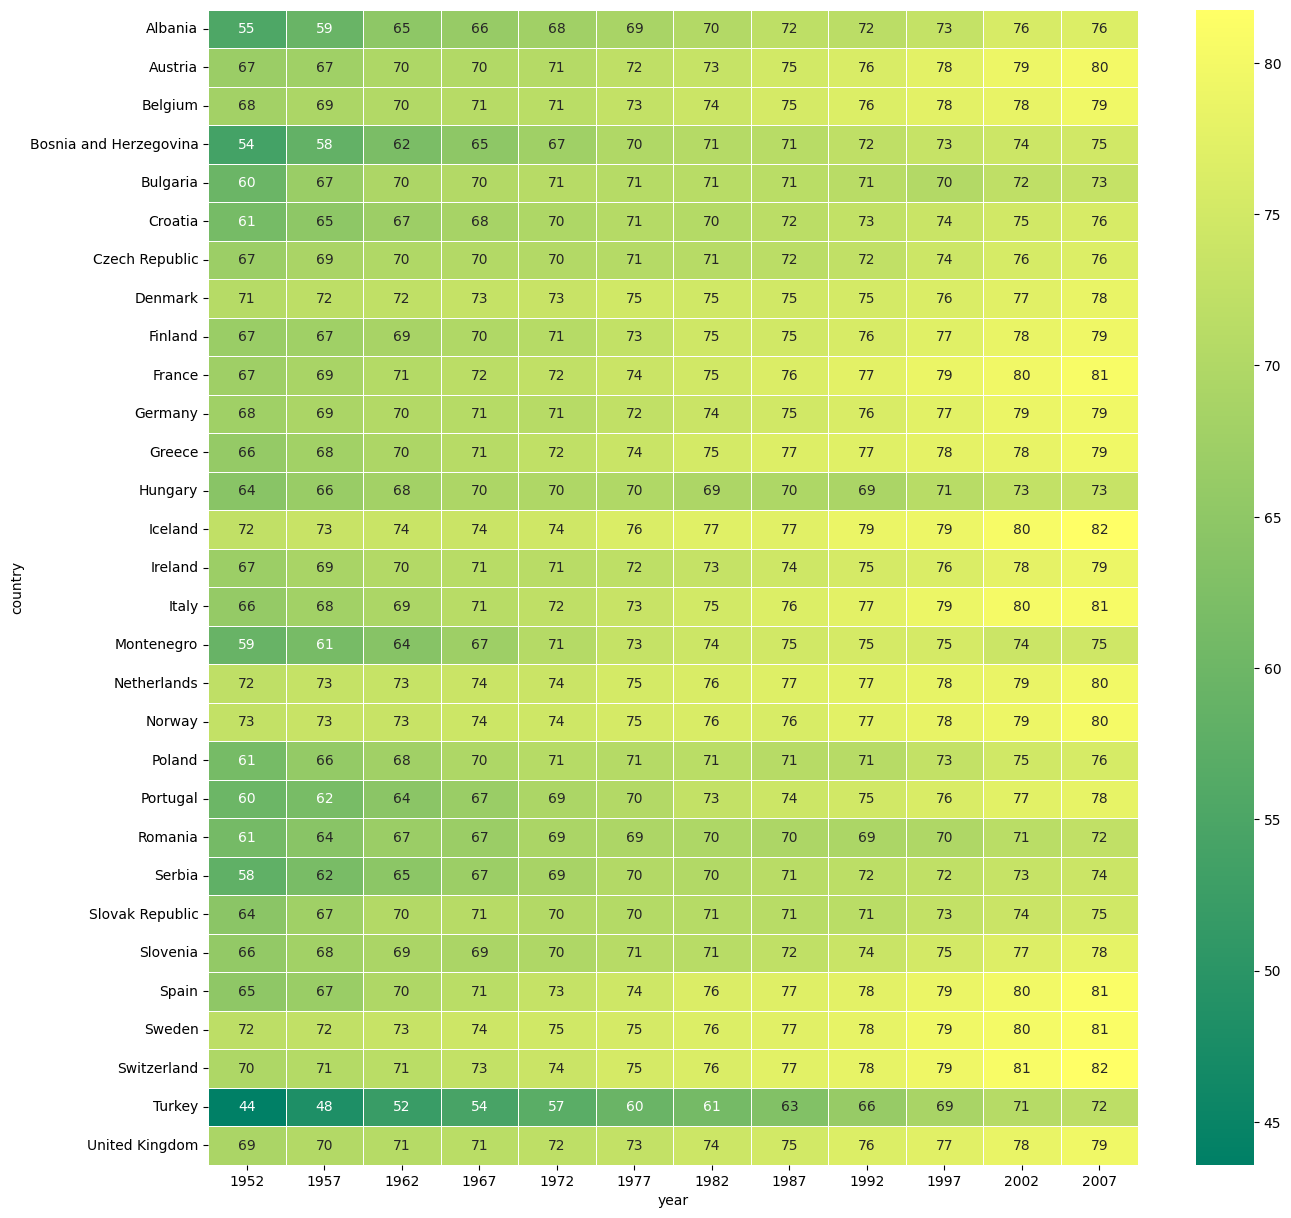

In [103]:
# annot 
temp_df = gap[gap['continent'] == 'Europe'].pivot(index='country', columns='year',values='lifeExp')
plt.figure(figsize=(15,15))
sns.heatmap(temp_df,annot=True,linewidth=0.5,cmap='summer')

In [104]:
# clustermap
# plot a matrix dataset as a hierarchically - clustered heatmap.
# This function requires scipy to be available

iris = px.data.iris()
iris


,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,3
146,6.3,2.5,5.0,1.9,virginica,3
147,6.5,3.0,5.2,2.0,virginica,3
148,6.2,3.4,5.4,2.3,virginica,3


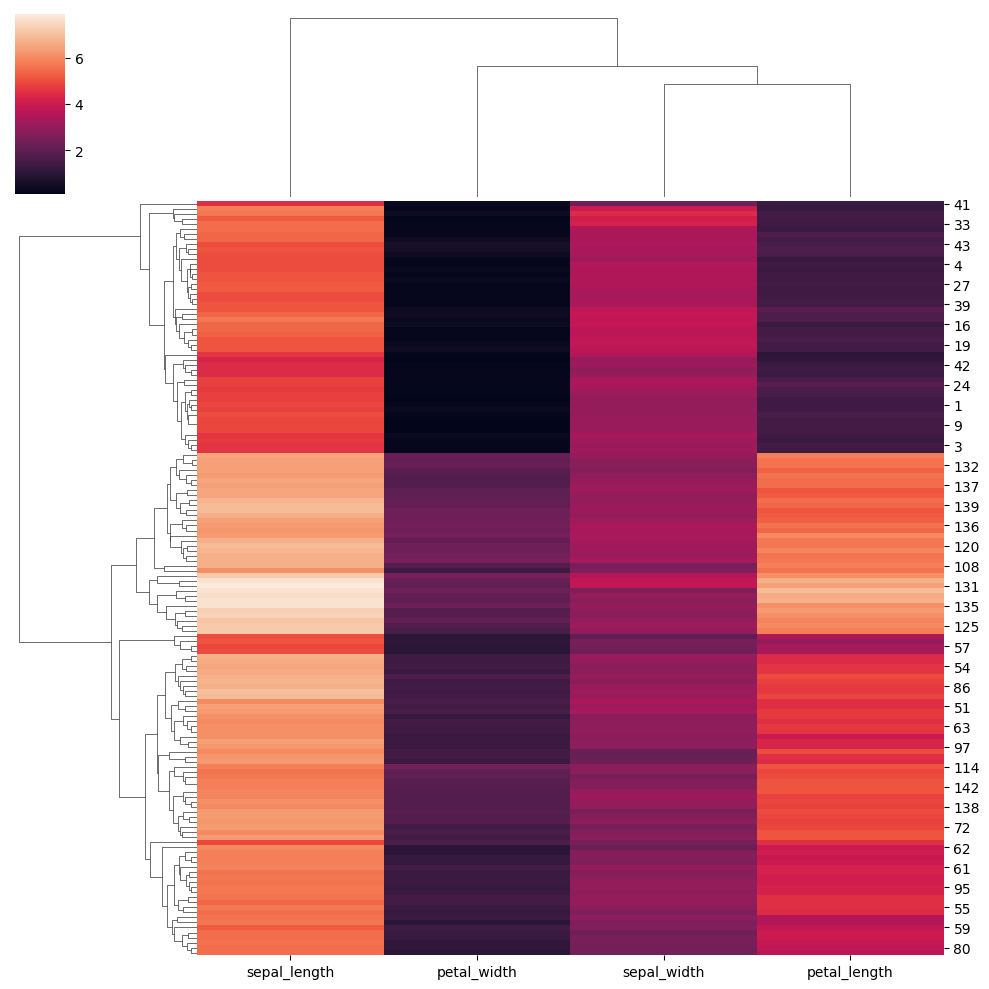

In [107]:
sns.clustermap(iris.iloc[:,[0,1,2,3]])